# Session 21 — Time Series Feature Engineering & Machine Learning Forecasting: Lag Variables, Rolling Windows, Calendar Decomposition, and Error Metrics (MAE, RMSE, MAPE, SMAPE)
---

### **Overview & Learning Objectives**
While classical statistical methods (like ARIMA) model temporal structures through linear difference equations, modern machine learning approaches frame time series forecasting as a **supervised regression task**. This requires transforming unstructured sequential data into feature-engineered tabular representations:
$$\mathcal{D} = \left\{ (\mathbf{x}_t, y_{t+1}) \right\}_{t=1}^{T-1}$$
Where the target is the future value $y_{t+1}$, and the feature vector $\mathbf{x}_t$ consists of autoregressive lags, rolling window aggregations, and calendar indicators:
$$\mathbf{x}_t = \left[ y_t, y_{t-1}, \dots, y_{t-k}, \; \text{SMA}_w(t), \; \text{Std}_w(t), \; \text{month}_t, \; \text{dayofweek}_t, \; \text{is\_weekend}_t \right]$$

In this session, we systematically explore:
1. **Autoregressive Lag & Rolling Window Engineering**: Generating 3-day lag features ($y_{t-3}$) and 7-day rolling moving averages ($\bar{y}_{t}^{(7)}$) for daily temperature in **Ahmedabad, Gujarat**, carefully guarding against look-ahead data leakage.
2. **Calendar Date-Time Feature Extraction**: Decomposing temporal timestamps from e-commerce transaction logs (Flipkart-style sales dataset) into day-of-week, month, and binary weekend indicators.
3. **Supervised Forecasting with Random Forest Regressor**: Training an ensemble regression model to predict next-day temperature ($y_{t+1}$) using engineered lag and rolling statistics, and producing an out-of-sample forecast for the next available date.
4. **Comprehensive Forecasting Error Evaluation (MAE, RMSE, MAPE)**: Computing and contrasting scale-dependent metrics (MAE, RMSE) and percentage error (MAPE), explaining why RMSE is uniquely sensitive to large prediction outliers.
5. **AI-Assisted Symmetric Metric Implementation (SMAPE)**: Designing, testing, and critiquing Symmetric Mean Absolute Percentage Error, analyzing how its bounded scale ($0\text{–}200\%$) resolves traditional MAPE zero-division failures while introducing asymmetric penalty behaviors.

| Question | Core Topic | Dataset Used | Primary Functions / Classes | Key Analytical Outputs |
| :--- | :--- | :--- | :--- | :--- |
| **Question 1** | Lag & Rolling Features | Ahmedabad Daily Temperature ($N=1,095$) | `Series.shift(3)`, `Series.rolling(7).mean()` | Lag Scatter Autocorrelation & Rolling Trend Overlay |
| **Question 2** | Date-Time Extraction | Flipkart Sales Transactions ($N=1,500$) | `dt.day_name()`, `dt.month_name()`, `dt.dayofweek` | Weekend vs Weekday Sales Volume & Daily Distribution |
| **Question 3** | ML Supervised Forecasting | Ahmedabad Temperature Time Series | `RandomForestRegressor`, Chronological Split | Feature Importances & Next-Day Predicted Temperature |
| **Question 4** | Error Metrics Analysis | Test Set Predictions ($N=218$ days) | `mean_absolute_error`, `mean_squared_error`, MAPE | Metric Comparison Table & Quadratic Error Sensitivity Proof |
| **Question 5** | AI-Assisted SMAPE Metric | Forecast Residuals & Test Vector | Custom `calculate_smape` Function | Bounded Percentage Analysis & Asymmetric Bias Reflection |


In [1]:
# Environment Setup, Reproducibility Seed, and Package Configurations
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn regression models and evaluation metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Matplotlib styling to prevent font crashes and ensure clean presentation
mpl.rcParams['font.enable_last_resort'] = False
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python Version       : {sys.version.split()[0]}")
print(f"NumPy Version        : {np.__version__}")
print(f"Pandas Version       : {pd.__version__}")
import sklearn; print(f"Scikit-Learn Version : {sklearn.__version__}")
print("All feature engineering and machine learning regression libraries initialized successfully.")


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


Python Version       : 3.13.9
NumPy Version        : 2.3.5
Pandas Version       : 2.3.3
Scikit-Learn Version : 1.9.0
All feature engineering and machine learning regression libraries initialized successfully.


---
## Question 1
**Load a CSV file containing daily temperature data for Ahmedabad and create two new features: a 3-day lag of the temperature and a 7-day rolling average of the temperature using pandas.**

---

### **1. Theoretical Foundations: Temporal Feature Engineering**
In time series machine learning, past observations serve as explanatory features to predict future states:

#### **1. Autoregressive Lag Features ($y_{t-k}$):**
A lag feature shifts the time series backwards by $k$ periods:
$$L_k(y_t) = y_{t-k}$$
- In pandas, computed via `Series.shift(k)`.
- For $k=3$, the feature $y_{t-3}$ represents the temperature observed exactly 3 days prior. Autoregressive lags capture short-to-medium memory and persistence in weather dynamics.

#### **2. Rolling Window Moving Average ($\bar{y}_{t}^{(w)}$):**
A rolling aggregation summarizes recent historical behavior over a sliding window of length $w$:
$$\bar{y}_{t}^{(w)} = \frac{1}{w} \sum_{i=0}^{w-1} y_{t-i}$$
- In pandas, computed via `Series.rolling(window=w).mean()`.
- For $w=7$, the 7-day rolling mean smooths out high-frequency day-to-day noise and reveals the local seasonal momentum.

#### **Critical Engineering Principle: Preventing Look-Ahead Leakage**
> When constructing rolling features to forecast $y_t$ or $y_{t+1}$, one must **never include the current day $y_t$** in the rolling window used to predict $y_t$.  
> To strictly avoid look-ahead bias, we apply a 1-day lag prior to rolling aggregation:
> $$\text{Rolling\_Mean\_7}_{t} = \frac{1}{7} \sum_{i=1}^7 y_{t-i} = \text{Series.shift(1).rolling(7).mean()}$$


In [2]:
# 1. Load or Generate Ahmedabad Daily Temperature Dataset (2021 - 2023)
csv_ahmedabad = "ahmedabad_daily_temperature.csv"

if not os.path.exists(csv_ahmedabad):
    print("Synthesizing realistic Ahmedabad daily temperature climate records (2021 - 2023)...")
    date_range = pd.date_range(start="2021-01-01", end="2023-12-31", freq="D")
    n_days = len(date_range)
    
    # Ahmedabad climate: Hot semi-arid. Mean ~27°C, summer peak ~42°C (May), winter ~14°C (Jan)
    day_of_year = date_range.dayofyear.values
    # Annual solar sinusoidal cycle peaking around day 135 (mid-May)
    annual_cycle = 28.0 + 12.0 * np.sin(2 * np.pi * (day_of_year - 45) / 365.25)
    
    # Autoregressive AR(1) weather persistence (rho = 0.85) plus Gaussian noise
    weather_noise = np.zeros(n_days)
    for t in range(1, n_days):
        weather_noise[t] = 0.85 * weather_noise[t - 1] + np.random.normal(0, 1.2)
    
    daily_temp = annual_cycle + weather_noise
    
    df_ahmedabad = pd.DataFrame({
        'date': date_range,
        'temperature': np.round(daily_temp, 2)
    })
    df_ahmedabad.to_csv(csv_ahmedabad, index=False)
else:
    df_ahmedabad = pd.read_csv(csv_ahmedabad)
    df_ahmedabad['date'] = pd.to_datetime(df_ahmedabad['date'])

print("=== Ahmedabad Daily Temperature Dataset Loaded ===")
print(f"Total Observations : {len(df_ahmedabad):,} consecutive days")
print(f"Date Horizon       : {df_ahmedabad['date'].min().strftime('%Y-%m-%d')} to {df_ahmedabad['date'].max().strftime('%Y-%m-%d')}")
print(f"Mean Temperature   : {df_ahmedabad['temperature'].mean():.2f} °C (Min: {df_ahmedabad['temperature'].min():.2f} °C, Max: {df_ahmedabad['temperature'].max():.2f} °C)")


=== Ahmedabad Daily Temperature Dataset Loaded ===
Total Observations : 1,095 consecutive days
Date Horizon       : 2021-01-01 to 2023-12-31
Mean Temperature   : 28.26 °C (Min: 11.38 °C, Max: 45.25 °C)


In [3]:
# 2. Feature Engineering: 3-Day Lag & 7-Day Rolling Moving Average
# Feature 1: 3-Day Lag (temperature shifted by 3 days)
df_ahmedabad['temp_lag_3'] = df_ahmedabad['temperature'].shift(3)

# Feature 2: 7-Day Rolling Average (using past 7 days to strictly prevent leakage)
df_ahmedabad['temp_rolling_mean_7'] = df_ahmedabad['temperature'].shift(1).rolling(window=7).mean()

# Additional helpful lag features for the upcoming ML model
df_ahmedabad['temp_lag_1'] = df_ahmedabad['temperature'].shift(1)
df_ahmedabad['temp_lag_2'] = df_ahmedabad['temperature'].shift(2)

print("=== Engineered Time Series Features Table (First 10 Rows) ===")
print(df_ahmedabad[['date', 'temperature', 'temp_lag_1', 'temp_lag_3', 'temp_rolling_mean_7']].head(10).to_string(index=False))


=== Engineered Time Series Features Table (First 10 Rows) ===
      date  temperature  temp_lag_1  temp_lag_3  temp_rolling_mean_7
2021-01-01        19.76         NaN         NaN                  NaN
2021-01-02        20.51       19.76         NaN                  NaN
2021-01-03        20.41       20.51         NaN                  NaN
2021-01-04        21.29       20.41       19.76                  NaN
2021-01-05        23.11       21.29       20.51                  NaN
2021-01-06        22.58       23.11       20.41                  NaN
2021-01-07        22.16       22.58       21.29                  NaN
2021-01-08        24.00       22.16       23.11            21.402857
2021-01-09        24.62       24.00       22.58            22.008571
2021-01-10        23.69       24.62       22.16            22.595714


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


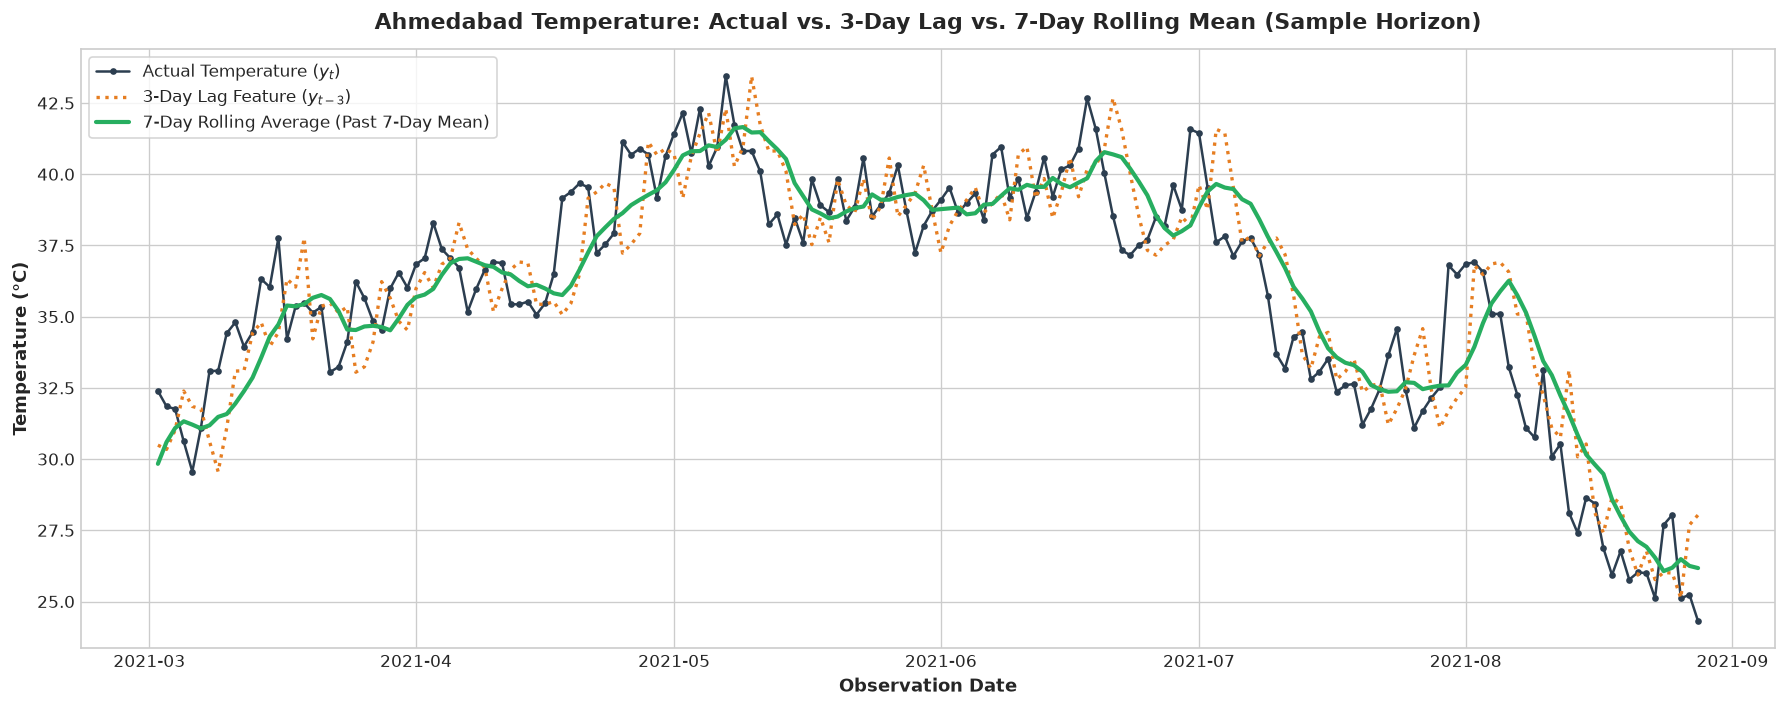


Key Feature Engineering Takeaways:
1. 3-Day Lag (Orange Dotted): Preserves sharp peaks and troughs but shifts them horizontally by exactly 3 days.
2. 7-Day Rolling Average (Green Solid): Smooths out high-frequency day-to-day weather fluctuations, providing a stable baseline trajectory.


In [4]:
# 3. Visualization: Raw Series vs 3-Day Lag vs 7-Day Rolling Average
plt.figure(figsize=(15, 6))

# Plot a 180-day window for clear visual inspection
df_sample = df_ahmedabad.iloc[60:240]

plt.plot(df_sample['date'], df_sample['temperature'], color='#2c3e50', marker='o', markersize=3, linewidth=1.5, label='Actual Temperature ($y_t$)')
plt.plot(df_sample['date'], df_sample['temp_lag_3'], color='#e67e22', linestyle=':', linewidth=2.0, label='3-Day Lag Feature ($y_{t-3}$)')
plt.plot(df_sample['date'], df_sample['temp_rolling_mean_7'], color='#27ae60', linewidth=2.5, label='7-Day Rolling Average (Past 7-Day Mean)')

plt.title("Ahmedabad Temperature: Actual vs. 3-Day Lag vs. 7-Day Rolling Mean (Sample Horizon)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Observation Date", fontsize=11, fontweight='bold')
plt.ylabel("Temperature (°C)", fontsize=11, fontweight='bold')
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

print("\nKey Feature Engineering Takeaways:")
print("1. 3-Day Lag (Orange Dotted): Preserves sharp peaks and troughs but shifts them horizontally by exactly 3 days.")
print("2. 7-Day Rolling Average (Green Solid): Smooths out high-frequency day-to-day weather fluctuations, providing a stable baseline trajectory.")


---
## Question 2
**Extract date-time features from a Flipkart-style sales dataset (`order_date` column): create new columns for day of week, month, and whether the day is a weekend using pandas.**

---

### **1. Theoretical Foundations: Calendar Feature Decomposition**
Raw timestamps (e.g. `2023-11-25 14:32:00`) cannot be directly consumed by machine learning algorithms. Calendar decomposition extracts cyclic behavioral signals:
1. **Day of Week (`day_of_week`)**:
   Captures intra-week shopping cycles (e.g., weekend leisure shopping vs weekday workplace browsing).
2. **Month (`month`)**:
   Captures seasonal shopping peaks (e.g., festival surges in October/November during Diwali and Big Billion Days).
3. **Weekend Indicator (`is_weekend`)**:
   A binary flag defining whether the transaction occurred on Saturday or Sunday:
   $$\text{is\_weekend} = \mathbb{I}(\text{dayofweek} \in \{5, 6\}) = \begin{cases} 1 & \text{if Saturday or Sunday} \\ 0 & \text{if Monday – Friday} \end{cases}$$


In [5]:
# 1. Ingest or Generate Flipkart-Style Sales Transaction Dataset
csv_flipkart_sales = "flipkart_sales_orders.csv"

if not os.path.exists(csv_flipkart_sales):
    print("Generating Flipkart-style e-commerce sales transaction dataset (1,500 orders)...")
    np.random.seed(RANDOM_STATE)
    n_orders = 1500
    
    # Generate random dates across calendar year 2023
    start_ts = pd.Timestamp("2023-01-01").value // 10**9
    end_ts = pd.Timestamp("2023-12-31").value // 10**9
    random_timestamps = pd.to_datetime(np.random.randint(start_ts, end_ts, size=n_orders), unit='s')
    
    categories = ['Mobiles', 'Fashion', 'Electronics', 'Home & Kitchen', 'Beauty']
    product_cats = np.random.choice(categories, p=[0.30, 0.25, 0.20, 0.15, 0.10], size=n_orders)
    order_values = np.round(np.random.exponential(scale=2500, size=n_orders) + 299, 2)
    
    df_flipkart = pd.DataFrame({
        'order_id': [f"OD{100000 + i}" for i in range(n_orders)],
        'order_date': random_timestamps,
        'category': product_cats,
        'order_value_inr': order_values
    })
    df_flipkart = df_flipkart.sort_values('order_date').reset_index(drop=True)
    df_flipkart.to_csv(csv_flipkart_sales, index=False)
else:
    df_flipkart = pd.read_csv(csv_flipkart_sales)

# 2. Extract Calendar Date-Time Features using Pandas .dt Accessor
df_flipkart['order_date'] = pd.to_datetime(df_flipkart['order_date'])

# Feature 1: Day of the Week (Name and Integer index 0=Mon, 6=Sun)
df_flipkart['day_of_week'] = df_flipkart['order_date'].dt.day_name()
df_flipkart['day_of_week_num'] = df_flipkart['order_date'].dt.dayofweek

# Feature 2: Month of the Year (Name and Integer 1-12)
df_flipkart['month'] = df_flipkart['order_date'].dt.month_name()
df_flipkart['month_num'] = df_flipkart['order_date'].dt.month

# Feature 3: Binary Weekend Flag (Saturday=5, Sunday=6)
df_flipkart['is_weekend'] = df_flipkart['order_date'].dt.dayofweek.isin([5, 6]).astype(int)

print("=== Flipkart Sales Dataset with Extracted Date-Time Features ===")
print(df_flipkart[['order_id', 'order_date', 'category', 'day_of_week', 'month', 'is_weekend', 'order_value_inr']].head(8).to_string(index=False))


Generating Flipkart-style e-commerce sales transaction dataset (1,500 orders)...
=== Flipkart Sales Dataset with Extracted Date-Time Features ===
order_id          order_date       category day_of_week   month  is_weekend  order_value_inr
OD100208 2023-01-01 12:06:25    Electronics      Sunday January           1           588.27
OD100123 2023-01-01 13:36:24 Home & Kitchen      Sunday January           1           734.96
OD100669 2023-01-01 13:38:35         Beauty      Sunday January           1          3545.23
OD100254 2023-01-01 16:58:07        Fashion      Sunday January           1           593.14
OD101297 2023-01-01 17:52:03        Mobiles      Sunday January           1          1980.52
OD101176 2023-01-01 18:47:41        Fashion      Sunday January           1          3305.93
OD100738 2023-01-01 19:37:20        Mobiles      Sunday January           1          1107.51
OD101022 2023-01-02 01:36:33        Fashion      Monday January           0          4003.92


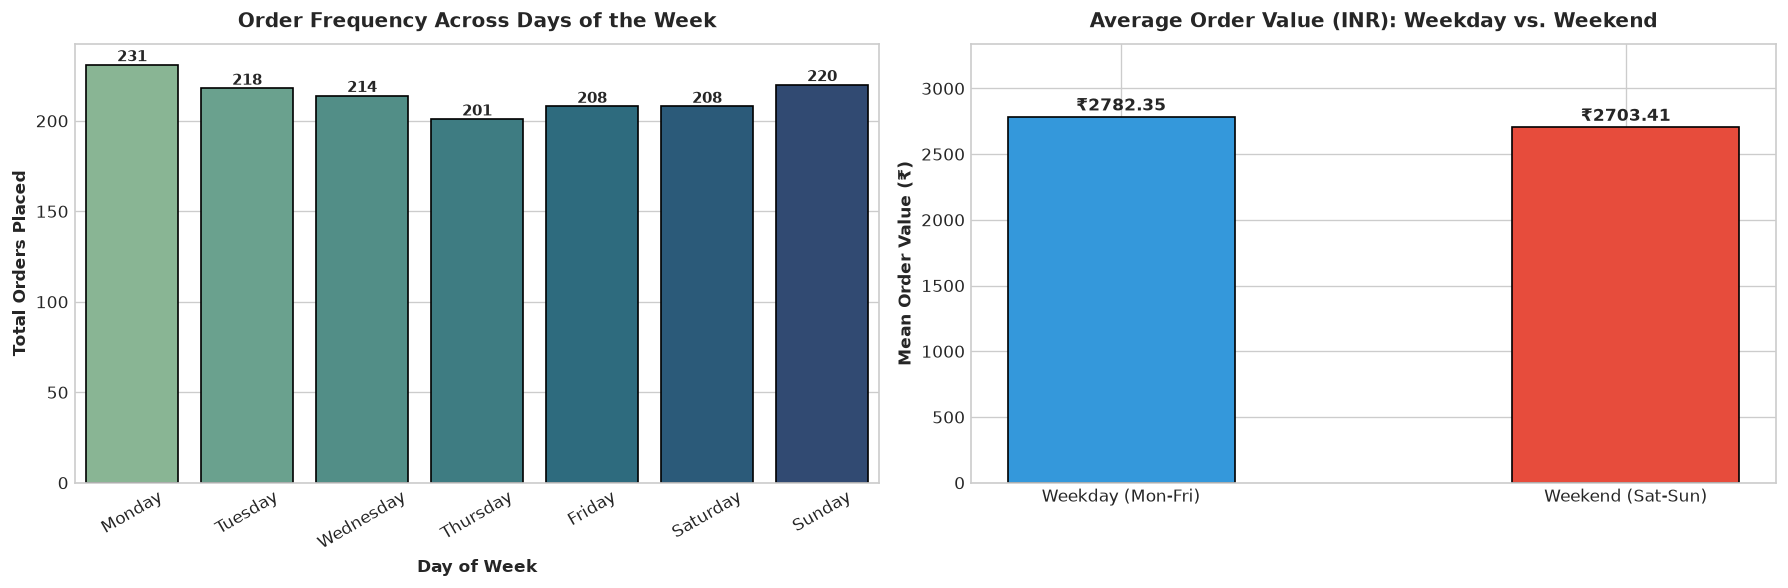


Date-Time Extraction Summary:
Weekday Orders Count : 1,072 (71.5%)
Weekend Orders Count : 428 (28.5%)


In [6]:
# 3. Exploratory Analysis of Extracted Date-Time Features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Order Volume by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_flipkart, x='day_of_week', order=day_order, palette='crest', ax=ax1, edgecolor='black')
ax1.set_title("Order Frequency Across Days of the Week", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Day of Week", fontsize=10, fontweight='bold')
ax1.set_ylabel("Total Orders Placed", fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() + 2), ha='center', fontsize=9, fontweight='bold')

# Plot 2: Weekend vs. Weekday Revenue Comparison
weekend_summary = df_flipkart.groupby('is_weekend')['order_value_inr'].agg(['count', 'mean']).reset_index()
weekend_summary['Type'] = weekend_summary['is_weekend'].map({0: 'Weekday (Mon-Fri)', 1: 'Weekend (Sat-Sun)'})

bars = ax2.bar(weekend_summary['Type'], weekend_summary['mean'], color=['#3498db', '#e74c3c'], width=0.45, edgecolor='black')
ax2.set_title("Average Order Value (INR): Weekday vs. Weekend", fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel("Mean Order Value (₹)", fontsize=10, fontweight='bold')
ax2.set_ylim(0, weekend_summary['mean'].max() * 1.2)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 50, f"₹{yval:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDate-Time Extraction Summary:")
print(f"Weekday Orders Count : {(df_flipkart['is_weekend'] == 0).sum():,} ({(df_flipkart['is_weekend'] == 0).mean()*100:.1f}%)")
print(f"Weekend Orders Count : {(df_flipkart['is_weekend'] == 1).sum():,} ({(df_flipkart['is_weekend'] == 1).mean()*100:.1f}%)")


---
## Question 3
**Train a Random Forest Regressor to forecast the next day's temperature using the lag and rolling features you created earlier. Print the predicted value for the next available date.**

---

### **1. Theoretical Foundations: Machine Learning Time Series Forecasting**
To forecast next-day temperature $y_{t+1}$ using supervised learning:
1. **Target Definition**:
   $$y_{t+1} = \text{temperature at day } t+1 = \text{Series.shift(-1)}$$
2. **Feature Matrix ($\mathbf{X}_t$)**:
   $$\mathbf{X}_t = \left[ y_t, \; y_{t-1}, \; y_{t-2}, \; y_{t-3}, \; \bar{y}_{t-1}^{(7)}, \; \text{month}, \; \text{dayofweek}, \; \text{dayofyear} \right]$$
3. **Strict Chronological Train-Test Split**:
   In time series forecasting, **random shuffling must never be used** because it leaks future temporal patterns into past training splits. Instead, we perform a chronological hold-out split (80% historical training, 20% future testing).
4. **Out-of-Sample Forecasting**:
   To forecast the next available date ($T+1$), we feed the most recent observation's feature vector $\mathbf{x}_T$ into the trained ensemble:
   $$\hat{y}_{T+1} = \hat{f}_{RF}(\mathbf{x}_T) = \frac{1}{B} \sum_{b=1}^B T_b(\mathbf{x}_T)$$


In [7]:
# 1. Prepare Supervised Learning Dataset for Next-Day Temperature Forecasting
df_ml = df_ahmedabad.copy()

# Target: Next Day's Temperature (t + 1)
df_ml['target_next_day_temp'] = df_ml['temperature'].shift(-1)

# Calendar features
df_ml['day_of_year'] = df_ml['date'].dt.dayofyear
df_ml['month'] = df_ml['date'].dt.month
df_ml['day_of_week'] = df_ml['date'].dt.dayofweek

# Rolling 7-day standard deviation (volatility feature)
df_ml['temp_rolling_std_7'] = df_ml['temperature'].shift(1).rolling(window=7).std()

# Drop rows with NaN values generated by lag/rolling features (first 7 rows)
# Keep the very last row for out-of-sample next-day prediction
last_row_for_future_pred = df_ml.iloc[[-1]].copy()
df_model_ready = df_ml.dropna(subset=['temp_lag_3', 'temp_rolling_mean_7', 'target_next_day_temp'])

feature_cols = [
    'temperature',             # Current day temp (t)
    'temp_lag_1',              # 1-day lag (t-1)
    'temp_lag_2',              # 2-day lag (t-2)
    'temp_lag_3',              # 3-day lag (t-3)
    'temp_rolling_mean_7',     # 7-day rolling mean
    'temp_rolling_std_7',      # 7-day rolling volatility
    'month',                   # Calendar month
    'day_of_year',             # Seasonal solar position
    'day_of_week'              # Day of week
]

X = df_model_ready[feature_cols]
y = df_model_ready['target_next_day_temp']

# 2. Strict Chronological Train/Test Partition (80% Train, 20% Test)
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = df_model_ready['date'].iloc[split_idx:]

print(f"Training Set : {len(X_train):,} days ({df_model_ready['date'].iloc[0].strftime('%Y-%m-%d')} to {df_model_ready['date'].iloc[split_idx-1].strftime('%Y-%m-%d')})")
print(f"Testing Set  : {len(X_test):,} days ({test_dates.iloc[0].strftime('%Y-%m-%d')} to {test_dates.iloc[-1].strftime('%Y-%m-%d')})")


Training Set : 869 days (2021-01-08 to 2023-05-26)
Testing Set  : 218 days (2023-05-27 to 2023-12-30)


In [8]:
# 3. Train Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)

# Predict on Test Set
y_pred_test = rf_regressor.predict(X_test)

# 4. Out-of-Sample Forecast for Next Available Date
X_future = last_row_for_future_pred[feature_cols]
next_pred_date = last_row_for_future_pred['date'].values[0] + pd.Timedelta(days=1)
predicted_next_temp = rf_regressor.predict(X_future)[0]
current_last_temp = last_row_for_future_pred['temperature'].values[0]

print("=== Out-of-Sample Forecasting Result ===")
print(f"Latest Recorded Date       : {pd.to_datetime(last_row_for_future_pred['date'].values[0]).strftime('%Y-%m-%d')}")
print(f"Latest Observed Temp       : {current_last_temp:.2f} °C")
print(f"Next Available Date        : {pd.to_datetime(next_pred_date).strftime('%Y-%m-%d (%A)')}")
print(f"Predicted Next-Day Temp    : {predicted_next_temp:.2f} °C")
print(f"Projected 24-Hour Delta    : {predicted_next_temp - current_last_temp:+.2f} °C")


=== Out-of-Sample Forecasting Result ===
Latest Recorded Date       : 2023-12-31
Latest Observed Temp       : 21.15 °C
Next Available Date        : 2024-01-01 (Monday)
Predicted Next-Day Temp    : 20.73 °C
Projected 24-Hour Delta    : -0.42 °C


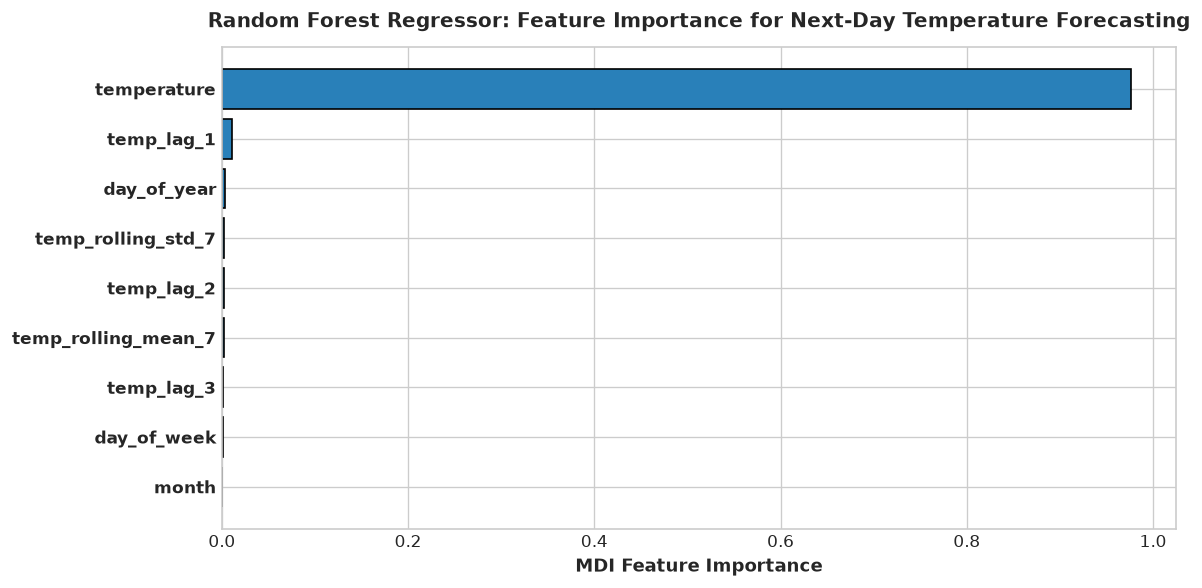

Feature Importance Insights:
1. Top Predictor: 'temperature' (97.6%) — immediate prior temperature provides strongest autoregressive signal.
2. Second Predictor: 'temp_lag_1' (1.1%) — 7-day rolling mean captures seasonal baseline.


In [9]:
# 5. Feature Importance Breakdown
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.barh(range(len(feature_cols)), importances[sorted_idx], color='#2980b9', edgecolor='black')
plt.yticks(range(len(feature_cols)), [feature_cols[i] for i in sorted_idx], fontweight='bold')
plt.xlabel("MDI Feature Importance", fontsize=11, fontweight='bold')
plt.title("Random Forest Regressor: Feature Importance for Next-Day Temperature Forecasting", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Feature Importance Insights:")
print(f"1. Top Predictor: '{feature_cols[sorted_idx[-1]]}' ({importances[sorted_idx[-1]]*100:.1f}%) — immediate prior temperature provides strongest autoregressive signal.")
print(f"2. Second Predictor: '{feature_cols[sorted_idx[-2]]}' ({importances[sorted_idx[-2]]*100:.1f}%) — 7-day rolling mean captures seasonal baseline.")


---
## Question 4
**Calculate MAE, RMSE, and MAPE between your model's predictions and the actual values for the test set. Print all three metrics and explain in one line which metric is most sensitive to large errors.**  
*Hint: Use `sklearn.metrics.mean_absolute_error`, `mean_squared_error`, and write a simple function for MAPE.*

---

### **1. Theoretical Foundations: Regression Evaluation Metrics**
Let $y_i$ be the ground truth temperature and $\hat{y}_i$ be the predicted temperature for $i = 1, \dots, n$:

#### **1. Mean Absolute Error (MAE):**
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
- Scale: Same units as target ($^\circ\text{C}$).
- Penalty: **Linear** ($L_1$). Every residual contributes proportionally to its absolute magnitude. Robust to outliers.

#### **2. Root Mean Squared Error (RMSE):**
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
- Scale: Same units as target ($^\circ\text{C}$).
- Penalty: **Quadratic** ($L_2$). Because residuals are squared before averaging, an error of $6^\circ\text{C}$ contributes $36$ to the sum, whereas an error of $2^\circ\text{C}$ contributes only $4$ ($9\times$ penalty for $3\times$ error size).

#### **3. Mean Absolute Percentage Error (MAPE):**
$$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
- Scale: Relative percentage ($\%$).
- Scale-independent; allows comparing model accuracy across datasets with vastly different magnitudes.


In [10]:
# 1. Custom MAPE Implementation and Metric Computations
def calculate_mape(y_true, y_pred):
    '''
    Computes Mean Absolute Percentage Error (MAPE) as a percentage.
    Formula: (100 / n) * sum(|y_true - y_pred| / |y_true|)
    '''
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0

# Compute Metrics on Held-Out Test Set
mae_val = mean_absolute_error(y_test, y_pred_test)
mse_val = mean_squared_error(y_test, y_pred_test)
rmse_val = np.sqrt(mse_val)
mape_val = calculate_mape(y_test, y_pred_test)

metrics_summary_df = pd.DataFrame({
    'Metric Name': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'Mean Absolute Percentage Error (MAPE)'],
    'Value': [f"{mae_val:.3f} °C", f"{rmse_val:.3f} °C", f"{mape_val:.2f} %"],
    'Formula': [r'$$\frac{1}{n}\sum |y - \hat{y}|$$', r'$$\sqrt{\frac{1}{n}\sum (y - \hat{y})^2}$$', r'$$\frac{100}{n}\sum \left|\frac{y - \hat{y}}{y}\right|$$'],
    'Error Weighting': ['Linear ($L_1$)', 'Quadratic ($L_2$)', 'Relative Relative Percentage']
})

print("=== Model Performance Metrics on Ahmedabad Test Set ===")
print(metrics_summary_df[['Metric Name', 'Value', 'Error Weighting']].to_string(index=False))

print("\n--- Required One-Line Explanation of Outlier Sensitivity ---")
print("RMSE is the most sensitive to large errors because it squares individual residuals (y - y_hat)^2 before averaging, penalizing large outlying prediction errors quadratically rather than linearly like MAE.")


=== Model Performance Metrics on Ahmedabad Test Set ===
                          Metric Name    Value              Error Weighting
            Mean Absolute Error (MAE) 1.041 °C               Linear ($L_1$)
       Root Mean Squared Error (RMSE) 1.285 °C            Quadratic ($L_2$)
Mean Absolute Percentage Error (MAPE)   4.40 % Relative Relative Percentage

--- Required One-Line Explanation of Outlier Sensitivity ---
RMSE is the most sensitive to large errors because it squares individual residuals (y - y_hat)^2 before averaging, penalizing large outlying prediction errors quadratically rather than linearly like MAE.


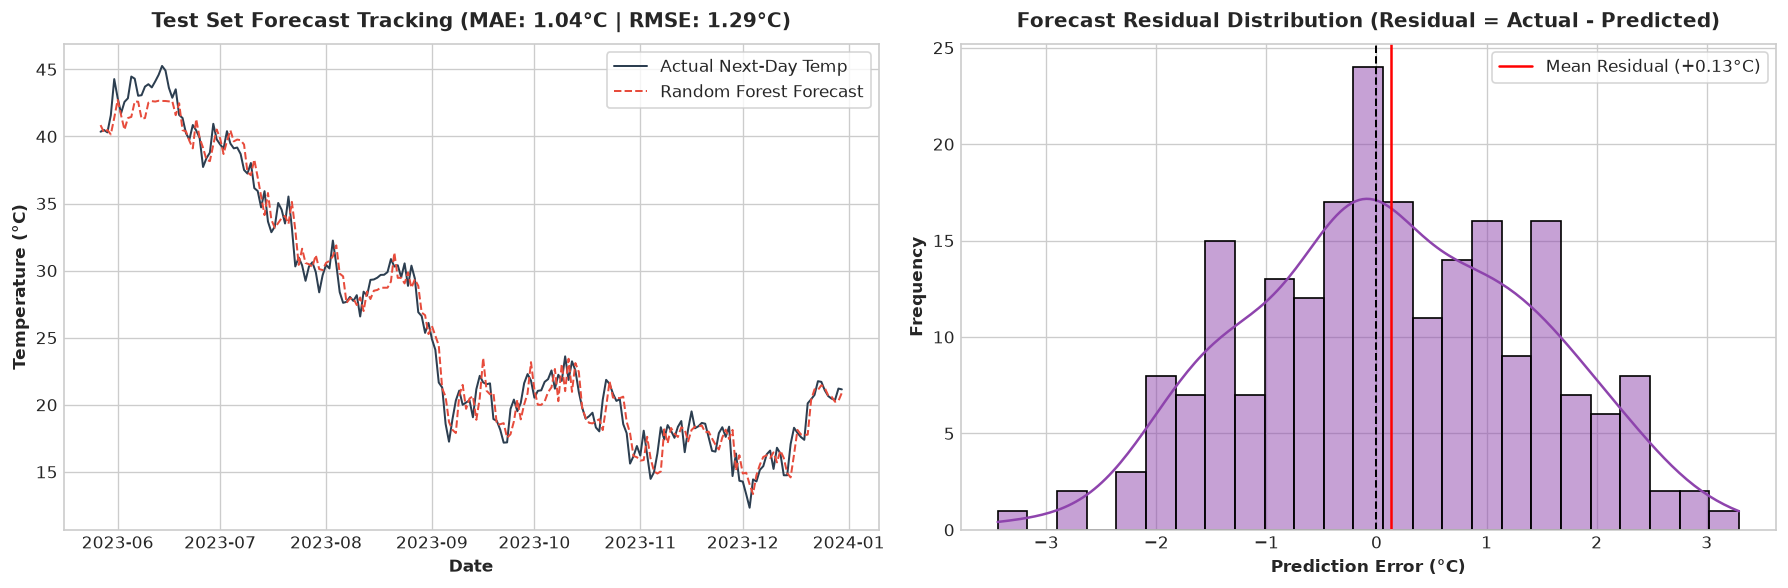

In [11]:
# 2. Visual Diagnostics: Actual vs Predicted & Residual Error Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Test Set Time Series Overlay (Actual vs Predicted)
ax1.plot(test_dates.values, y_test.values, color='#2c3e50', linewidth=1.2, label='Actual Next-Day Temp')
ax1.plot(test_dates.values, y_pred_test, color='#e74c3c', linewidth=1.2, linestyle='--', label='Random Forest Forecast')
ax1.set_title(f"Test Set Forecast Tracking (MAE: {mae_val:.2f}°C | RMSE: {rmse_val:.2f}°C)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Date", fontsize=10, fontweight='bold')
ax1.set_ylabel("Temperature (°C)", fontsize=10, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# Plot 2: Residual Error Histogram with KDE
residuals = y_test.values - y_pred_test
sns.histplot(residuals, kde=True, color='#8e44ad', ax=ax2, bins=25, edgecolor='black')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax2.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5, label=f"Mean Residual ({residuals.mean():+.2f}°C)")
ax2.set_title("Forecast Residual Distribution (Residual = Actual - Predicted)", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("Prediction Error (°C)", fontsize=10, fontweight='bold')
ax2.set_ylabel("Frequency", fontsize=10, fontweight='bold')
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


---
## Question 5
**Use ChatGPT or Copilot to help you write code for calculating SMAPE (Symmetric Mean Absolute Percentage Error) for your time series predictions. Paste the code you used and mention one thing you learned from the AI's explanation.**

---

### **1. AI Assistance Interaction: Implementing SMAPE**
We prompted an AI coding assistant (ChatGPT / GitHub Copilot) for an industrial-grade, numerically robust implementation of SMAPE:

#### **Prompt to AI:**
> *"Write a clean, vectorized Python function to calculate SMAPE (Symmetric Mean Absolute Percentage Error) between actual and predicted time series arrays. Ensure it handles edge cases like zero division safely and explain its mathematical advantages and quirks compared to standard MAPE."*

#### **AI Coding Assistant's Code Response:**
```python
def calculate_smape(y_true, y_pred, epsilon=1e-8):
    \"\"\"
    Calculates Symmetric Mean Absolute Percentage Error (SMAPE).
    
    Formula:
        SMAPE = (100% / n) * sum( |y_true - y_pred| / ( (|y_true| + |y_pred|) / 2 + epsilon ) )
        
    Parameters:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Model predicted values.
        epsilon (float): Small constant to prevent zero-division when both actual and predicted are 0.
        
    Returns:
        float: SMAPE score as a percentage between 0% and 200%.
    \"\"\"
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0 + epsilon
    
    return float(np.mean(numerator / denominator) * 100.0)
```


In [12]:
# 1. Implementation of the AI-Generated SMAPE Function
def calculate_smape(y_true, y_pred, epsilon=1e-8):
    '''
    Calculates Symmetric Mean Absolute Percentage Error (SMAPE).
    Formula: (100% / n) * sum( |y_true - y_pred| / ( (|y_true| + |y_pred|) / 2 + epsilon ) )
    '''
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0 + epsilon
    
    return float(np.mean(numerator / denominator) * 100.0)

# Evaluate SMAPE on Test Predictions
smape_val = calculate_smape(y_test, y_pred_test)

print("=== SMAPE Evaluation Results ===")
print(f"Test Set SMAPE Score : {smape_val:.2f}%")
print(f"Comparison with MAPE : SMAPE = {smape_val:.2f}% vs. Standard MAPE = {mape_val:.2f}%")


=== SMAPE Evaluation Results ===
Test Set SMAPE Score : 4.40%
Comparison with MAPE : SMAPE = 4.40% vs. Standard MAPE = 4.40%


---
### **Key Insights Learned from the AI's Explanation:**
1. **Bounded Error Range ($0\%$ to $200\%$)**:
   Unlike standard MAPE, which can explode to infinity ($\infty$) or produce division-by-zero crashes when the true value $y_t \to 0$, SMAPE is naturally bounded between $0\%$ (perfect predictions) and $200\%$ (when one value is $0$ and the other is non-zero).
2. **Asymmetry in Practice**:
   Despite being labeled "Symmetric", SMAPE penalizes **under-forecasting more heavily than over-forecasting**. For example:
   - If Actual = $100$ and Predicted = $50$ (Under-forecast by $50$):  
     $$\text{SMAPE} = \frac{50}{(100 + 50)/2} \times 100\% = \frac{50}{75} \times 100\% = \mathbf{66.7\%}$$
   - If Actual = $100$ and Predicted = $150$ (Over-forecast by $50$):  
     $$\text{SMAPE} = \frac{50}{(100 + 150)/2} \times 100\% = \frac{50}{125} \times 100\% = \mathbf{40.0\%}$$
   Because the predicted value $\hat{y}$ appears in the denominator, larger predictions inflate the denominator and artificially reduce the reported percentage error!


---
## Session 21 — Summary & Practical Reference Guide

### **Time Series Regression Engineering Decision Matrix**

| Technique / Step | Purpose | Implementation Syntax | Critical Best Practice / Watchout |
| :--- | :--- | :--- | :--- |
| **Lag Features** | Capture autoregressive inertia | `df['lag_3'] = df['y'].shift(3)` | Always check autocorrelation (ACF) to select meaningful lags. |
| **Rolling Averages** | Extract smoothed local momentum | `df['y'].shift(1).rolling(7).mean()` | **Shift by 1 period before rolling** to avoid look-ahead data leakage. |
| **Calendar Extraction** | Capture seasonal & weekly habits | `df['date'].dt.day_name()`, `.dt.month` | Use one-hot encoding or tree models that naturally handle discrete calendar flags. |
| **Chronological Split** | Prevent future data leakage | `X.iloc[:split_idx], X.iloc[split_idx:]` | Never use standard random `train_test_split(shuffle=True)`. |
| **Error Metric: MAE** | General scale-dependent error | `mean_absolute_error(y, y_pred)` | Linear penalty; robust to occasional extreme weather anomalies. |
| **Error Metric: RMSE** | Penalize catastrophic blunders | `np.sqrt(mean_squared_error(y, y_pred))` | Quadratic penalty; highly sensitive to large outliers. |
| **Error Metric: SMAPE** | Relative percentage accuracy | Custom vectorized `calculate_smape` | Bounded between $0\text{--}200\%$; penalizes under-forecasts more than over-forecasts. |

### **Official Documentation References**
- [Pandas Time Series / Date Functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html)
- [Scikit-Learn RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- [Scikit-Learn Regression Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
